In [2]:
import numpy as np

def load_images(file_path):
    with open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28)

def load_labels(file_path):
    with open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data


In [4]:
X_train = load_images('../data/train-images-idx3-ubyte/train-images-idx3-ubyte')
y_train = load_labels('../data/train-labels-idx1-ubyte/train-labels-idx1-ubyte')

X_test = load_images('../data/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
y_test = load_labels('../data/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')


In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
from sklearn import svm

model = svm.SVC(kernel='rbf', C=5, gamma=0.05)
model.fit(X_train[:10000], y_train[:10000])  # limit for speed

,C,5
,kernel,'rbf'
,degree,3
,gamma,0.05
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test[:2000])
print("Accuracy:", accuracy_score(y_test[:2000], y_pred))

Accuracy: 0.956


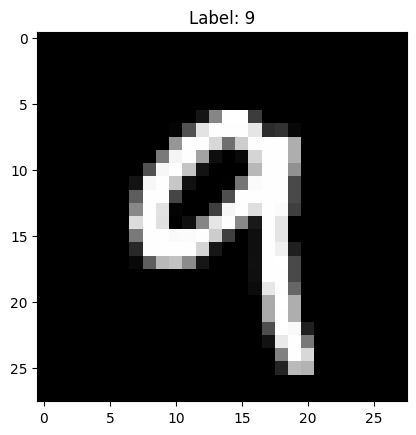

In [17]:
import matplotlib.pyplot as plt

plt.imshow(X_train[110].reshape(28,28), cmap='gray')
plt.title(f"Label: {y_train[110]}")
plt.show()

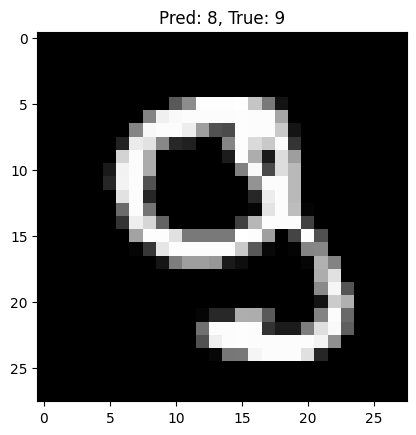

In [20]:
wrong = np.where(y_pred != y_test[:2000])[0]

plt.imshow(X_test[wrong[1]].reshape(28,28), cmap='gray')
plt.title(f"Pred: {y_pred[wrong[1]]}, True: {y_test[wrong[1]]}")
plt.show()